<a href="https://colab.research.google.com/github/VedantPatil0525/100-days-of-Deep-Learning/blob/main/Day_02_Perceptron_Trick/Day_02_Perceptron_Trick.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41, hypercube=False, class_sep=10)

In [2]:
import matplotlib.pyplot as plt

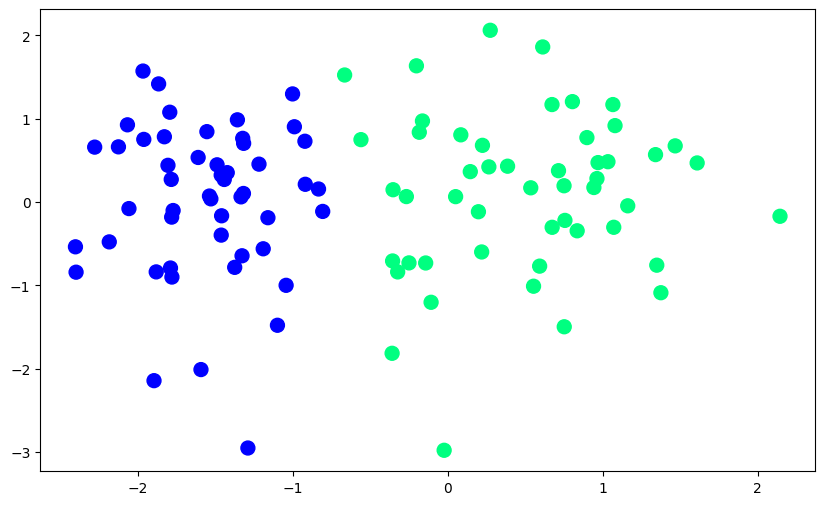

In [3]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)

In [21]:
def perceptron(X, y):

  X=np.insert(X, 0, 1, axis=1)
  weights = np.ones(X.shape[1])
  lr = 0.1

  for i in range(1000):
    j = np.random.randint(0, 100)
    y_hat = step(np.dot(X[j], weights))
    weights = weights + lr*(y[j]-y_hat)*X[j]

  return weights[0], weights[1:]

In [22]:
def step(z):
  return 1 if z>0 else 0

In [23]:
intercept_, coef_ = perceptron(X, y)

In [24]:
print(coef_)
print(intercept_)

[1.28295471 0.06991131]
1.0


In [26]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [27]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input+b

(-3.0, 2.0)

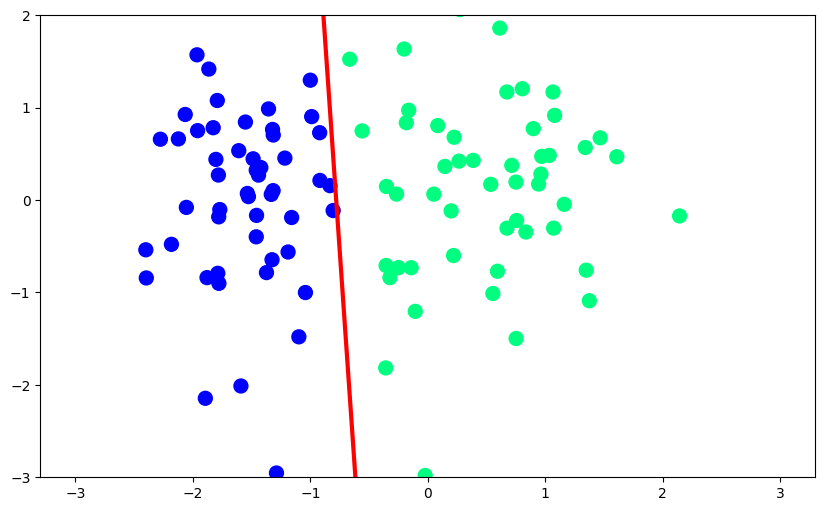

In [29]:
plt.figure(figsize=(10,6))
plt.plot(x_input, y_input, color='red', linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [30]:
def perceptron(X, y):

  m = []
  b = []

  X=np.insert(X, 0, 1, axis=1)
  weights = np.ones(X.shape[1])
  lr = 0.1

  for i in range(200):
    j = np.random.randint(0, 100)
    y_hat = step(np.dot(X[j], weights))
    weights = weights + lr*(y[j]-y_hat)*X[j]

    m.append(-(weights[1]/weights[2]))
    b.append(-(weights[0]/weights[2]))

  return m, b

In [31]:
m,b = perceptron(X,y)

In [45]:
%matplotlib inline
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

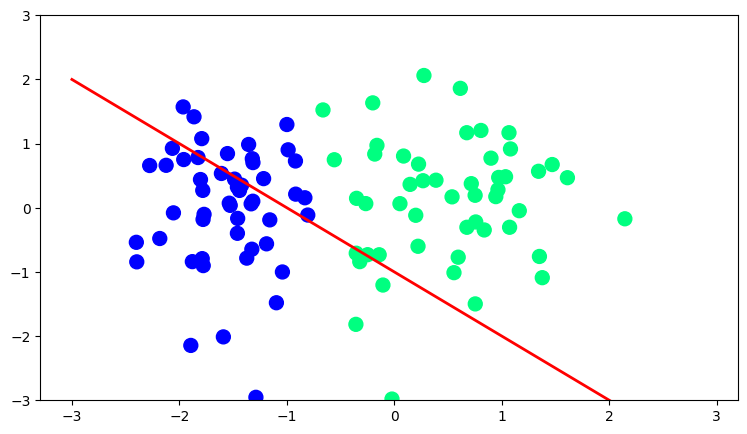

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots(figsize=(9,5))

x_i = np.arange(-3, 3, 0.1)

# Initial line
line, = ax.plot(x_i, x_i*m[0] + b[0], 'r-', linewidth=2)

# Scatter points
ax.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)

plt.ylim(-3, 3)

def update(i):
    label = f'epoch {i+1}'
    line.set_ydata(x_i*m[i] + b[i])
    ax.set_xlabel(label)
    return line,

anim = FuncAnimation(
    fig,
    update,
    frames=len(m),   # safer than 200
    interval=100,
    repeat=True
)

plt.show()